# Model Predictions

This notebooks purpose is to compare the predicted states to the actual states infeered from the open window

In [32]:
import matplotlib.pyplot as plt
from src.utils import load_model
from src.data import load_and_aggregate_data
import jax.numpy as jnp
import numpy as np
import os 
from dotenv import load_dotenv

In [33]:
df = load_and_aggregate_data()
ys = jnp.array(df["CO2C"].values)
window_indicator = jnp.array(df["WindowClosed"].values)
df

,HalfHour,CO2C,WindowClosed,Time,Day,Month,Hour
0,24,501.640625,0.5,0.020833,18.0,3.0,11.500000
1,25,636.562500,1.0,0.041667,18.0,3.0,12.000000
2,26,636.562500,1.0,0.062500,18.0,3.0,12.666667
3,27,626.875000,1.0,0.083333,18.0,3.0,13.000000
4,28,536.145833,1.0,0.104167,18.0,3.0,13.666667
...,...,...,...,...,...,...,...
1661,5,1299.583333,1.0,34.625000,22.0,4.0,2.000000
1662,6,1300.000000,1.0,34.645833,22.0,4.0,2.666667
1663,7,1118.645833,1.0,34.666667,22.0,4.0,3.000000
1664,8,1269.270833,1.0,34.687500,22.0,4.0,3.666667


In [34]:
BASE_MODEL_PATH = os.getenv("MODEL_PATH") + "/"
BASE_MODEL_PATH

'/Users/madshaakonsson/Desktop/7-semester/hmm-modelling/results/models/'

In [35]:
#Finding first 00 in data 
time = df["Time"].values
start_idx = np.where(time == 1)[0][0]
hours = df["Hour"].values
start_idx = np.where(hours == 0)[0][0]
print(f"First 00 in data at index: {start_idx}, time: {time[start_idx]}={time[start_idx]*24}, hour: {hours[start_idx]}")

First 00 in data at index: 25, time: 0.5416666666666666=13.0, hour: 0.0


In [36]:
#Finding first 00 in data 
time = df["Time"].values
start_idx = np.where(time == 1)[0][0]
hour = df["Hour"].values
start_idx = np.where(hour == 0)[0][0]
print(f"First 00 in data at index: {start_idx}, time: {time[start_idx]}={time[start_idx]*24}, hour: {hour[start_idx]}")

First 00 in data at index: 25, time: 0.5416666666666666=13.0, hour: 0.0


### Checking First Model

In [37]:
def plot_predictions(model, ys, window_indicator, start_time=0, timesteps=48, state=0):
    """
    Plots the first 24 hours of predictions from the model against the actual data.
    """
    # Get the first 24 hours of data

    y_true = ys[start_time:start_time + timesteps] #Co2 levels indicating occupant presence
    ws = window_indicator[start_time:start_time + timesteps] #Avg. of the open anc closed window indicator per 30 min interval
    state_results = model.state_results #State results from the model
    ut = jnp.asarray(state_results.ut).T #Inferrred states for the current time step 
    utt = jnp.asarray(state_results.utt).T #predicted states for the current time step
    ut = ut[state, start_time:start_time + timesteps] #Inferrred states for the current time step
    utt = utt[state, start_time:start_time + timesteps] #predicted states for the current time step 


    timesteps = range(timesteps) 
    plt.figure(figsize=(12, 6))
    plt.plot(timesteps, y_true, label='True CO2 Levels', color='blue') #Plot on a secondary y-axis
    plt.legend()
    plt.twinx()
    plt.plot(timesteps, ws, label='Window Indicator', color='orange')
    plt.plot(timesteps, ut, label='Predicted States (ut)', color='green')
    plt.plot(timesteps, utt, label='Inffered States (utt)', color='red')
    plt.xlabel('Time Steps (30 min intervals)')
    plt.ylabel('Values')
    plt.title('Model Predictions vs True CO2 Levels')
    plt.legend()
    plt.grid()
    plt.show()


def collapse_to_base_states(probs, order):
    """
    Collapse the augmented-state probabilities of a higher-order HMM to the K base
    current-state marginals.

    A K-state order-`d` HMM carries K**d augmented states (s_{t-d+1}, ..., s_t). The
    augmented index i decodes so the current state s_t is `i % K`, so reshaping to
    (..., K, T) and summing the leading axes marginalises out the history and yields
    the probability of being in each base state at time t. For a first-order model
    (order=1) this is a no-op. `probs` has shape (num_states, T).
    """
    n_aug = probs.shape[0]
    if order <= 1:
        return probs
    k = int(round(n_aug ** (1.0 / order)))
    return probs.reshape(-1, k, probs.shape[1]).sum(axis=0)  # (k, T)


def plot_predictions_all_states(model, ys, window_indicator, hours=None, start_time=0, timesteps=47):
    """
    Plots the predictions from the model against the actual data, split across 4 subplots (one for each state).

    The x-axis is the hour of the day. Each timestep is a 30-minute interval, so the
    axis advances by 0.5 h per step, anchored at the clock hour of `start_time`
    (taken from `hours`). If `hours` is not given it falls back to hours elapsed
    from the start of the window.

    For higher-order HMMs the augmented states (s_{t-1}, s_t, ...) are collapsed to
    the base current-state marginals, so the four subplots show the actual state
    probabilities and sum to 1 across states at every timestep.
    """
    from matplotlib.ticker import FuncFormatter, MultipleLocator

    # Get the data for the specified time window
    y_true = ys[start_time:start_time + timesteps] 
    ws = window_indicator[start_time:start_time + timesteps] 
    state_results = model.state_results 
    ut = jnp.asarray(state_results.ut).T 
    utt = jnp.asarray(state_results.utt).T 

    # Collapse augmented states to base current-state marginals for higher-order HMMs
    # (no-op for first-order models). Without this a second-order model would show 4
    # of its 16 augmented states, which do not sum to 1.
    order = int(getattr(model.transition, "order", 1))
    ut = collapse_to_base_states(ut, order)
    utt = collapse_to_base_states(utt, order)

    # Build a continuous hour-of-day axis: 0.5 h per 30-min timestep. Anchor at the
    # clock hour of the first timestep (rounded to the nearest half hour, since the
    # aggregated Hour column holds fractional means).
    if hours is not None:
        start_hour = round(float(hours[start_time]) * 2) / 2
    else:
        start_hour = 0.0
    x_hours = start_hour + 0.5 * np.arange(timesteps)
    print(f"Plotting from hour {start_hour % 24:.1f} for {timesteps} timesteps (30 min each).")

    # Create a 4x1 grid of subplots, sharing the x-axis
    fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 16), sharex=True)
    
    # Ensure axes is iterable even if someone changes nrows to 1 in the future
    if not isinstance(axes, np.ndarray):
        axes = [axes]
        
    for state, ax in enumerate(axes):
        # Safety check: break if there are fewer states than subplots
        if state >= ut.shape[0]: 
            break 
            
        # 1. Plot True CO2 on the primary y-axis
        ax.plot(x_hours, y_true, label='True CO2 Levels', color='blue', linewidth=2)
        ax.set_ylabel('CO2 Levels', color='blue')
        ax.tick_params(axis='y', labelcolor='blue')
        ax.grid(True, alpha=0.3)
        
        # 2. Create a secondary y-axis for the indicator and states
        ax2 = ax.twinx()
        
        # 3. Plot the window indicator and state arrays on the secondary axis
        ut_slice = ut[state, start_time:start_time + timesteps]
        utt_slice = utt[state, start_time:start_time + timesteps]
        
        ax2.plot(x_hours, ws, label='Window Indicator', color='orange', alpha=0.5)
        ax2.plot(x_hours, ut_slice, label=f'Predicted (ut)', color='green', linestyle='--')
        ax2.plot(x_hours, utt_slice, label=f'Inferred (utt)', color='red', linestyle=':')
        
        ax2.set_ylabel(f'State {state} Probs / Indicator')
        
        # 4. Combine legends for both axes so they don't overlap
        lines_1, labels_1 = ax.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=9)
        
        ax.set_title(f'State {state} Predictions vs Actuals')

    # Label the shared x-axis with clock hours (wrap at 24). Ticks every 2 hours.
    axes[-1].xaxis.set_major_locator(MultipleLocator(2))
    axes[-1].xaxis.set_major_formatter(FuncFormatter(lambda v, _pos: f"{int(round(v)) % 24:02d}"))
    axes[-1].set_xlabel('Hour of day')
    
    # Use tight_layout to prevent subplot titles and labels from overlapping
    plt.tight_layout()
    plt.show()


In [38]:
MODEL = "ar_hmm.pkl"
model = load_model(BASE_MODEL_PATH + MODEL)

Plotting from hour 12.5 for 48 timesteps (30 min each).


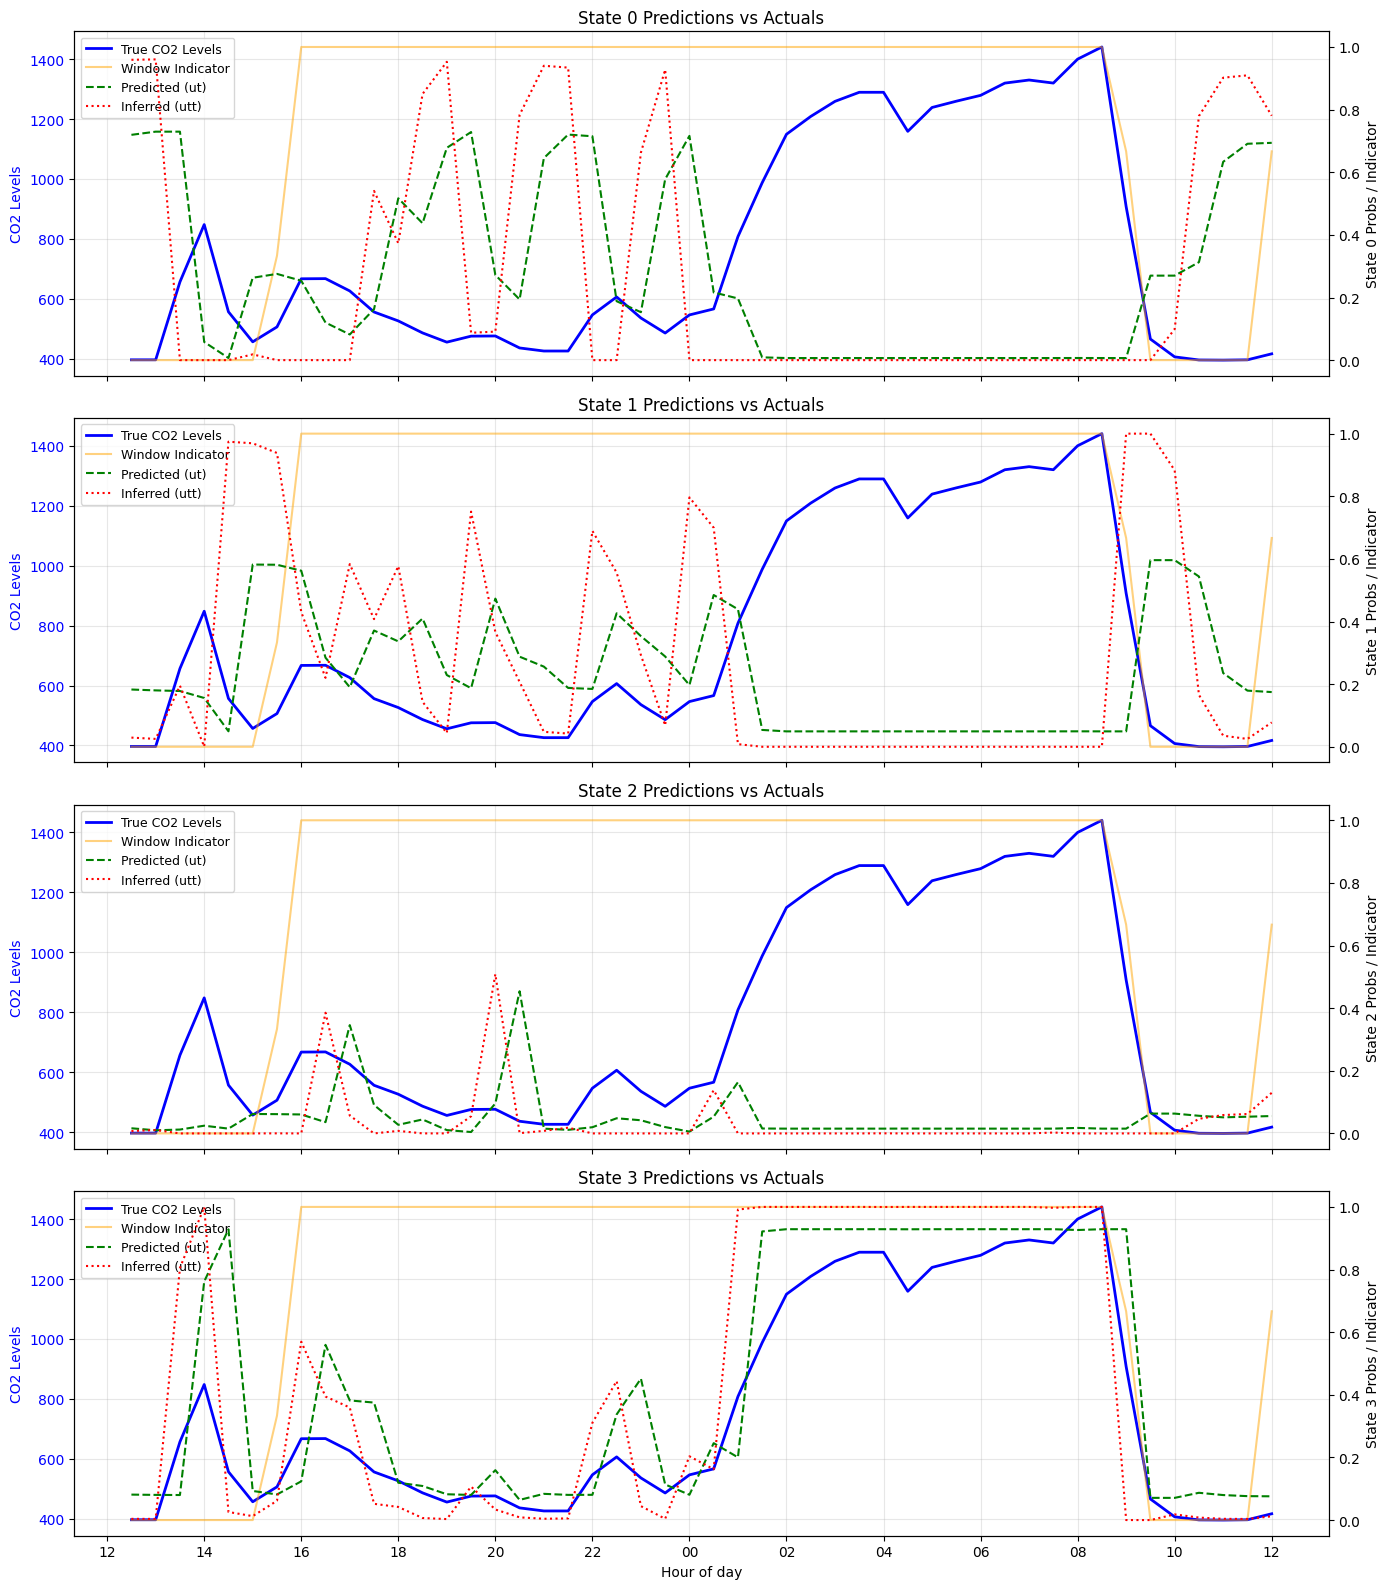

In [39]:
plot_predictions_all_states(model, ys, window_indicator,hours, start_time=50, timesteps=48)

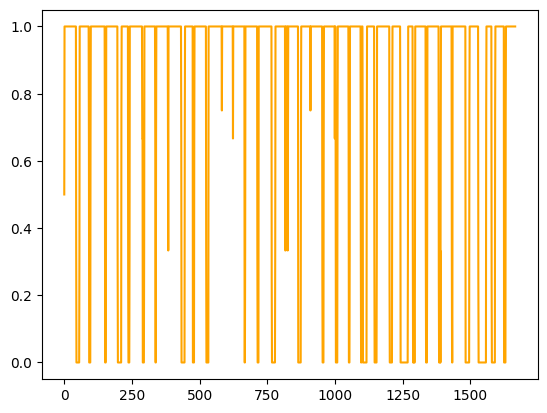

In [40]:
plt.plot(window_indicator, label='Window Indicator', color='orange')

Model: ordinary_hmm.pkl
Plotting from hour 0.0 for 54 timesteps (30 min each).


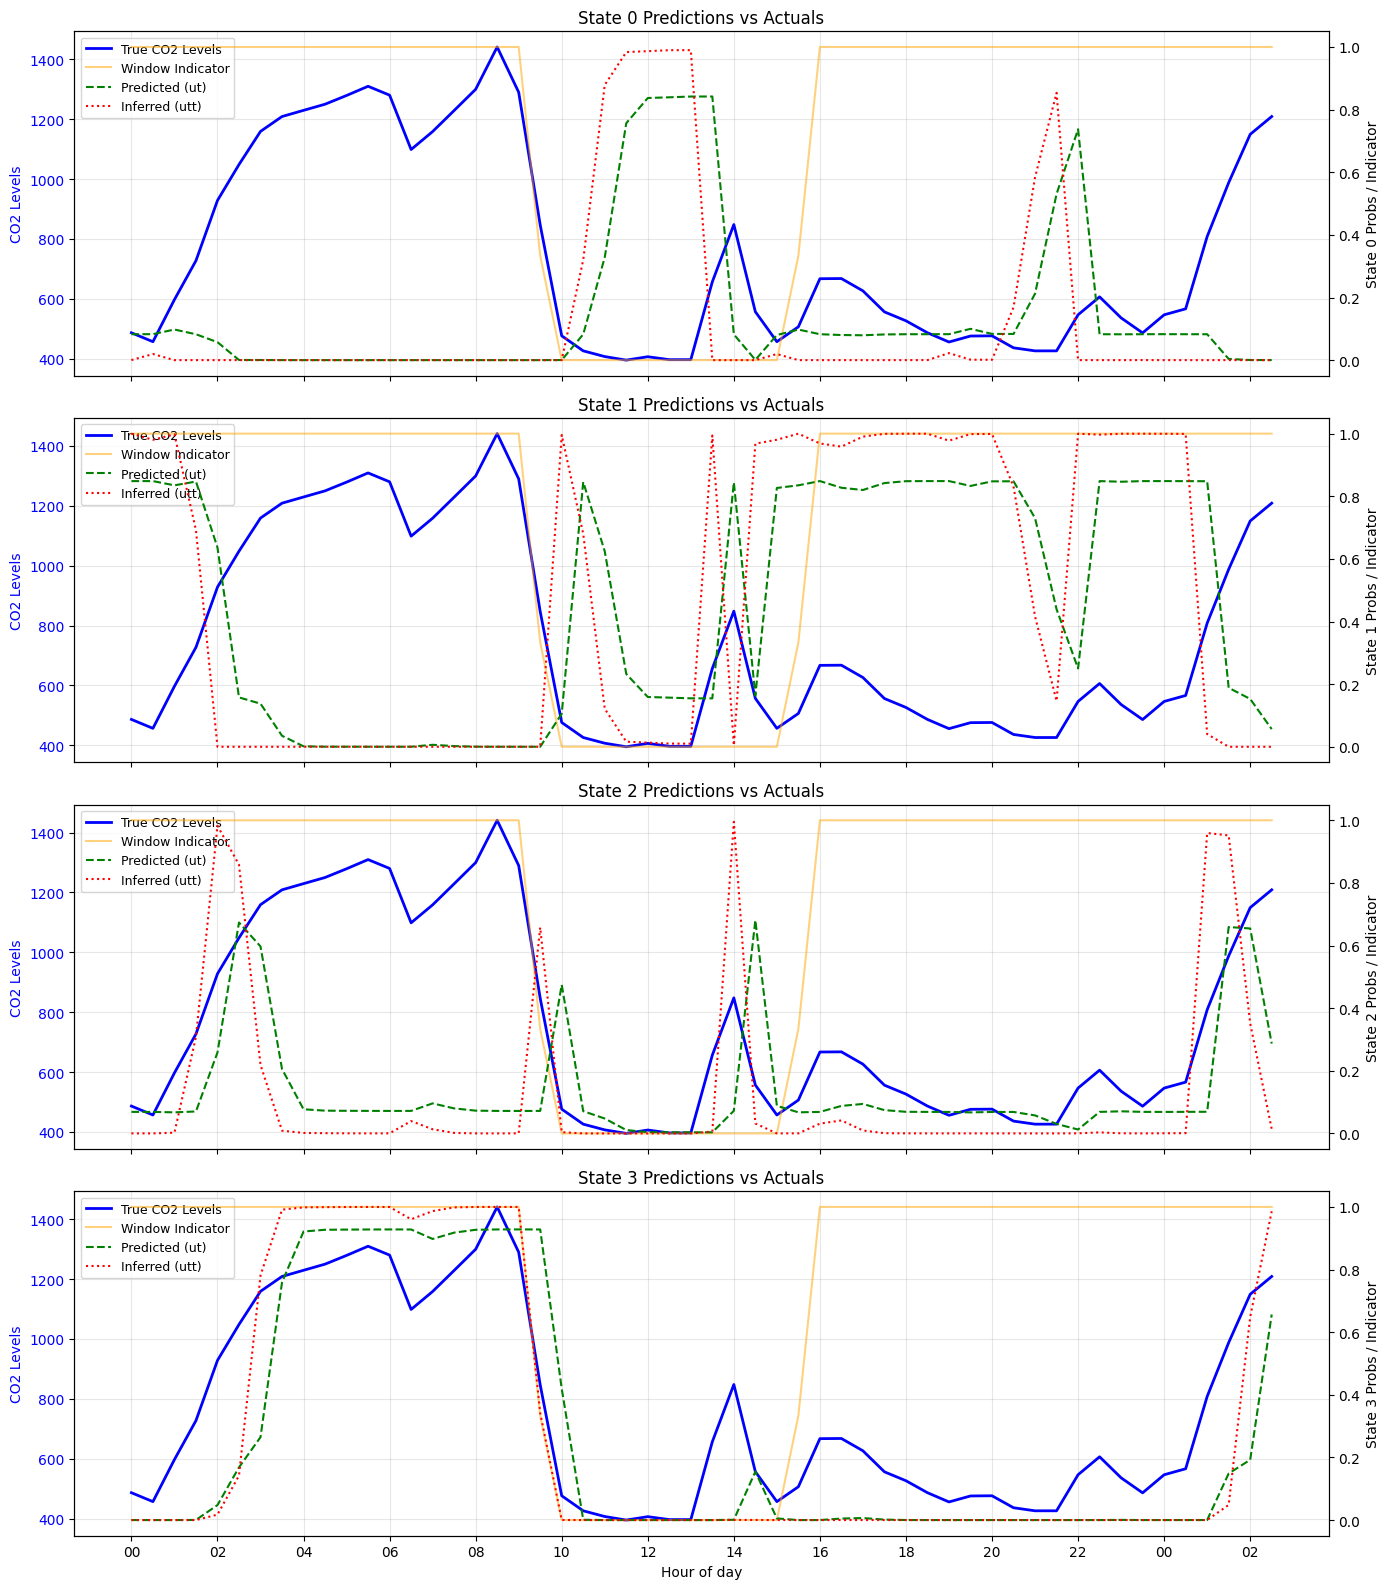

Model: ar_hmm.pkl
Plotting from hour 0.0 for 54 timesteps (30 min each).


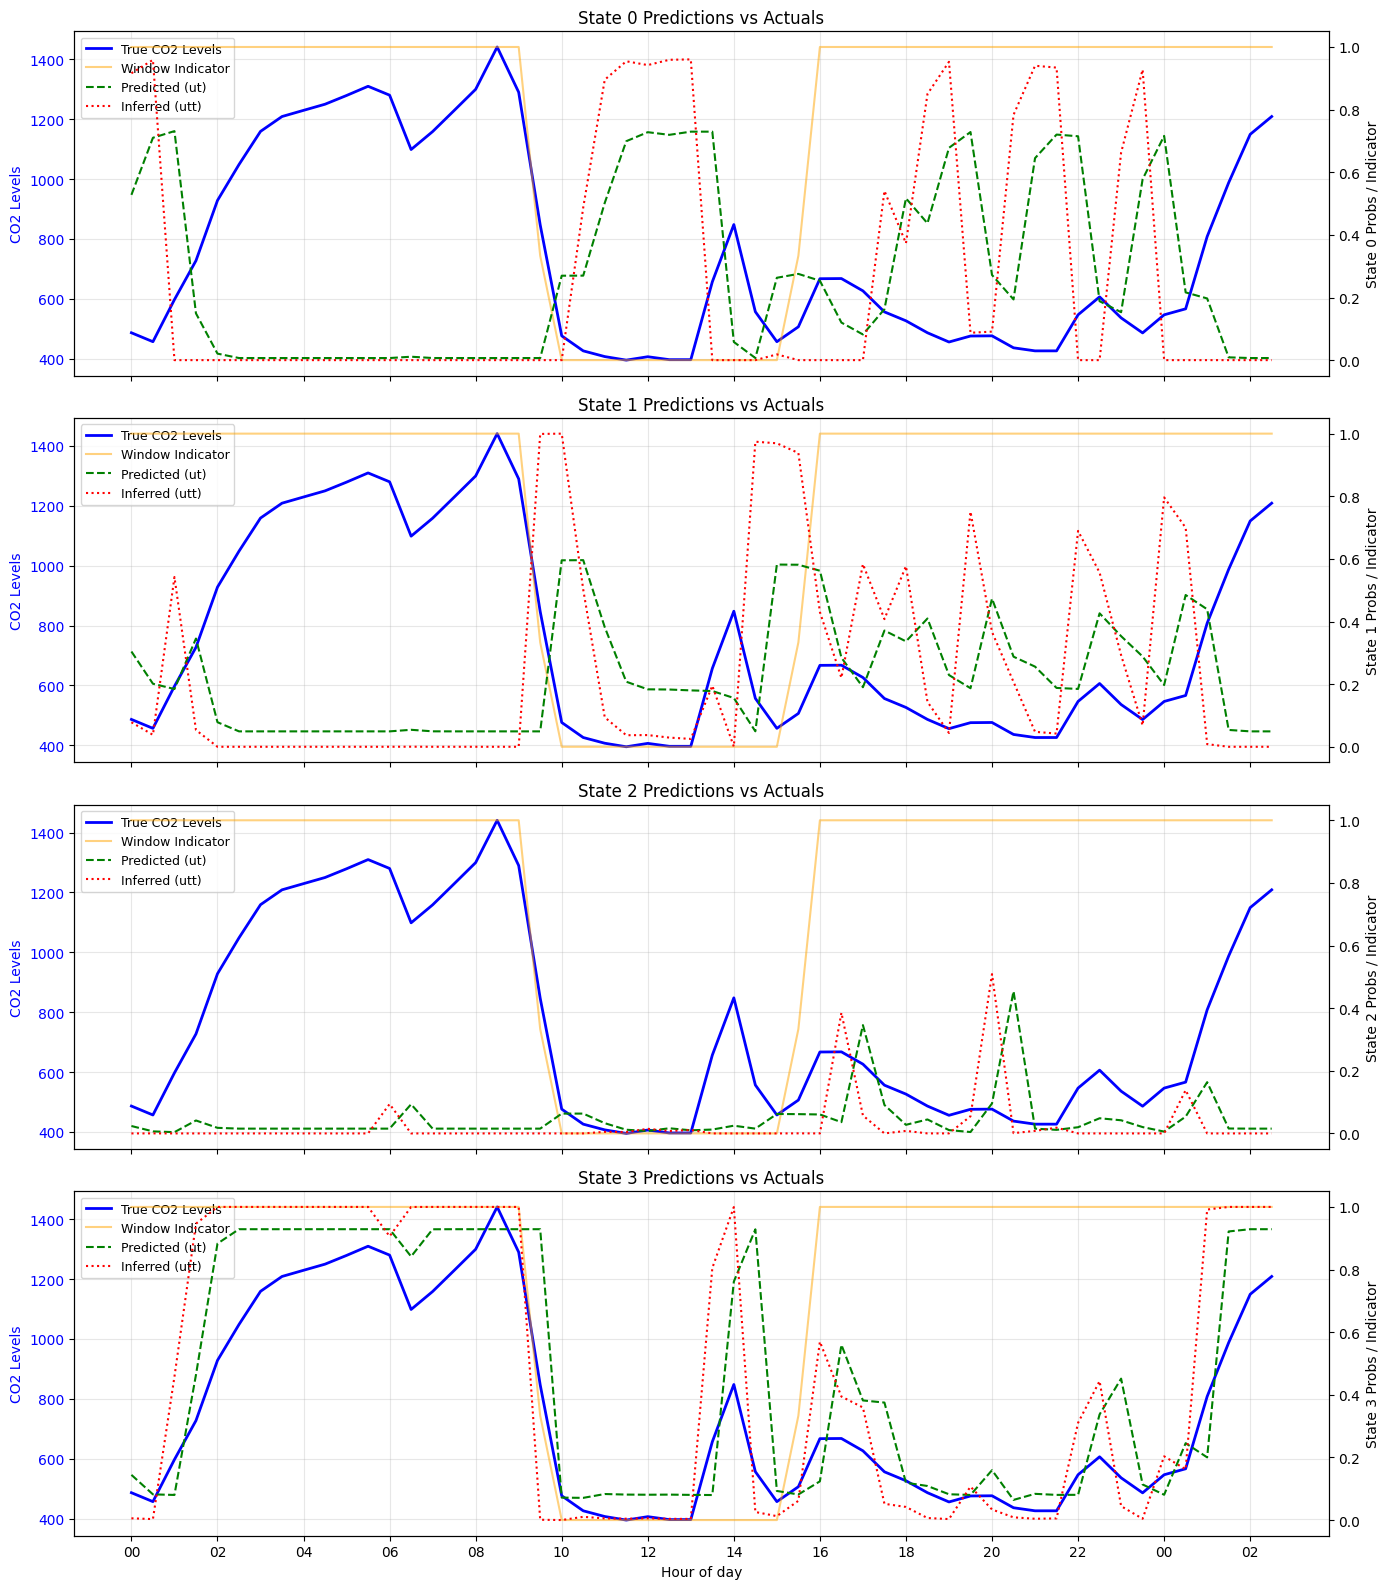

Model: ar_2_hmm.pkl
Plotting from hour 0.0 for 54 timesteps (30 min each).


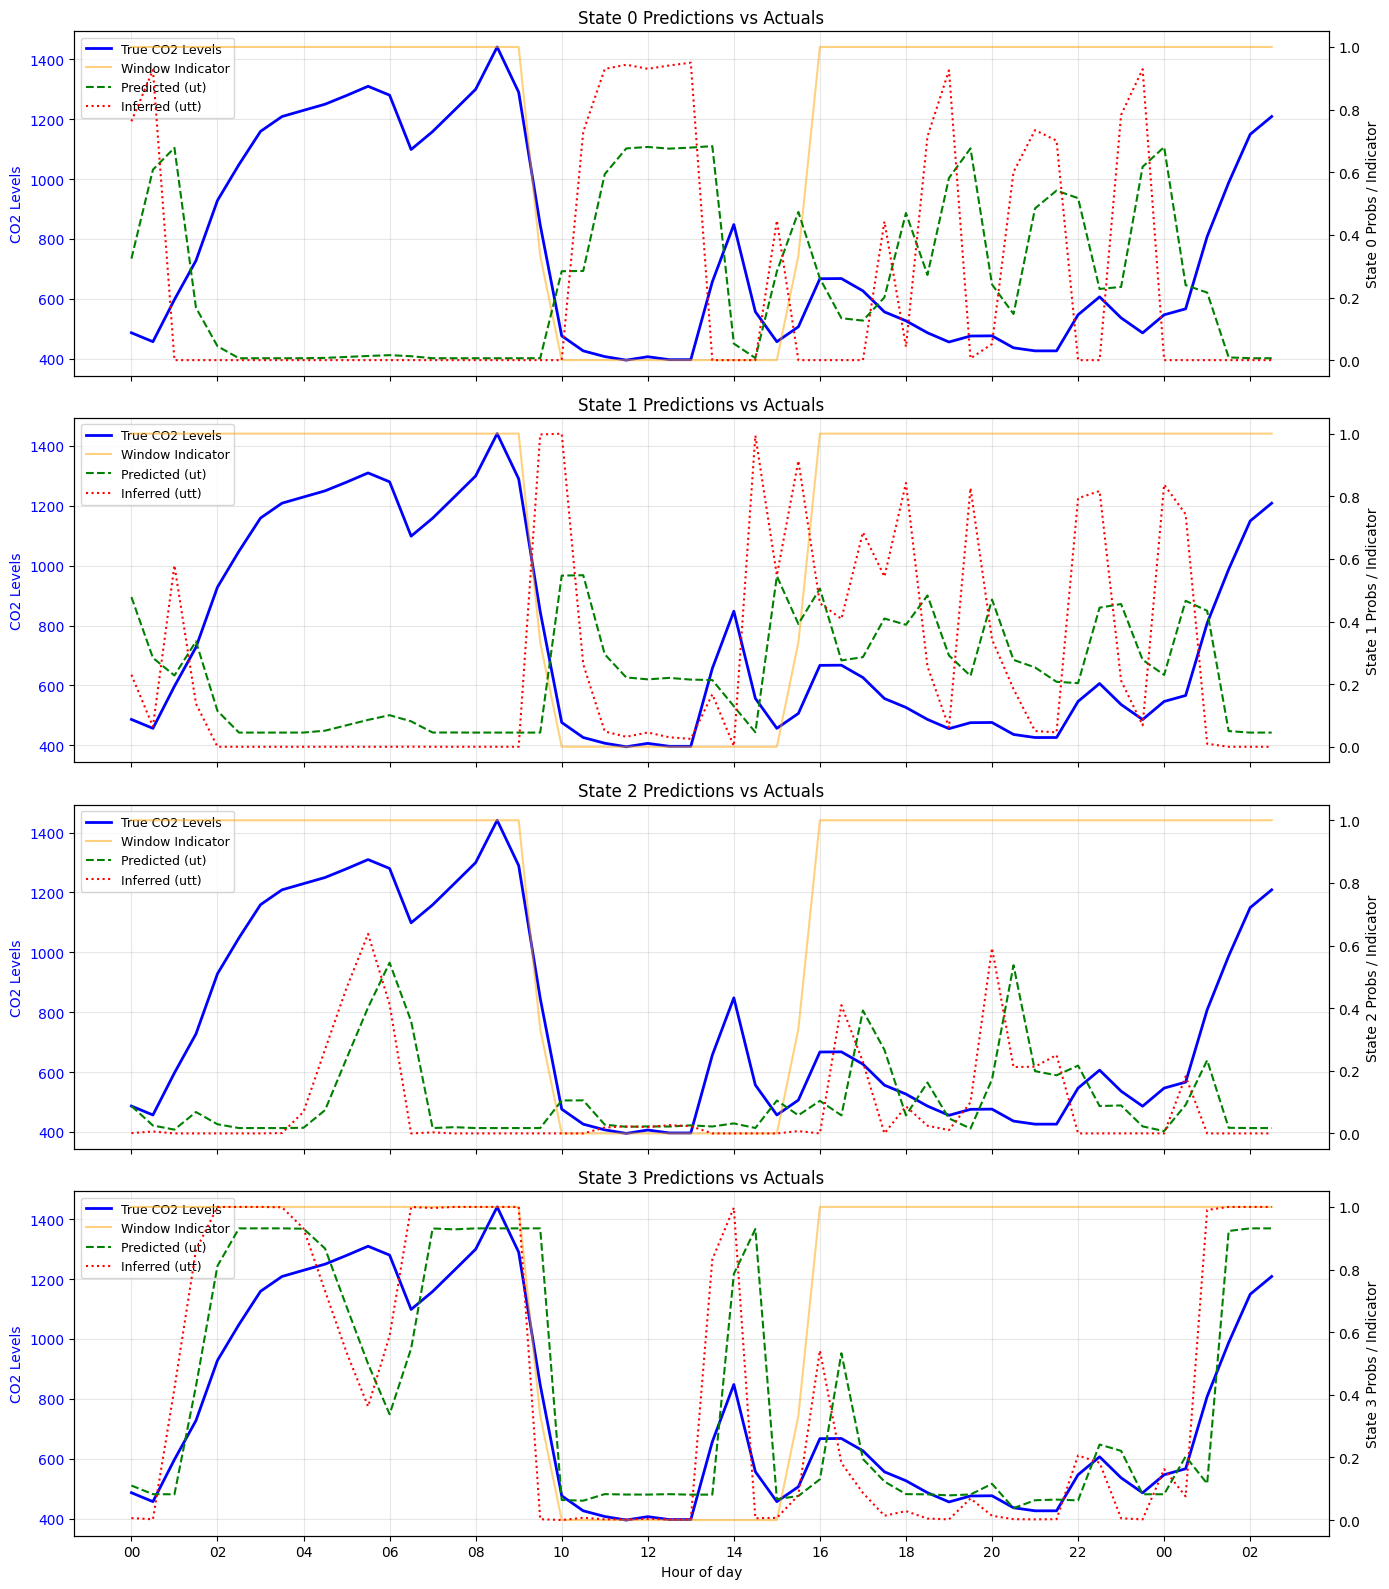

Model: second_order_hmm.pkl
Plotting from hour 0.0 for 54 timesteps (30 min each).


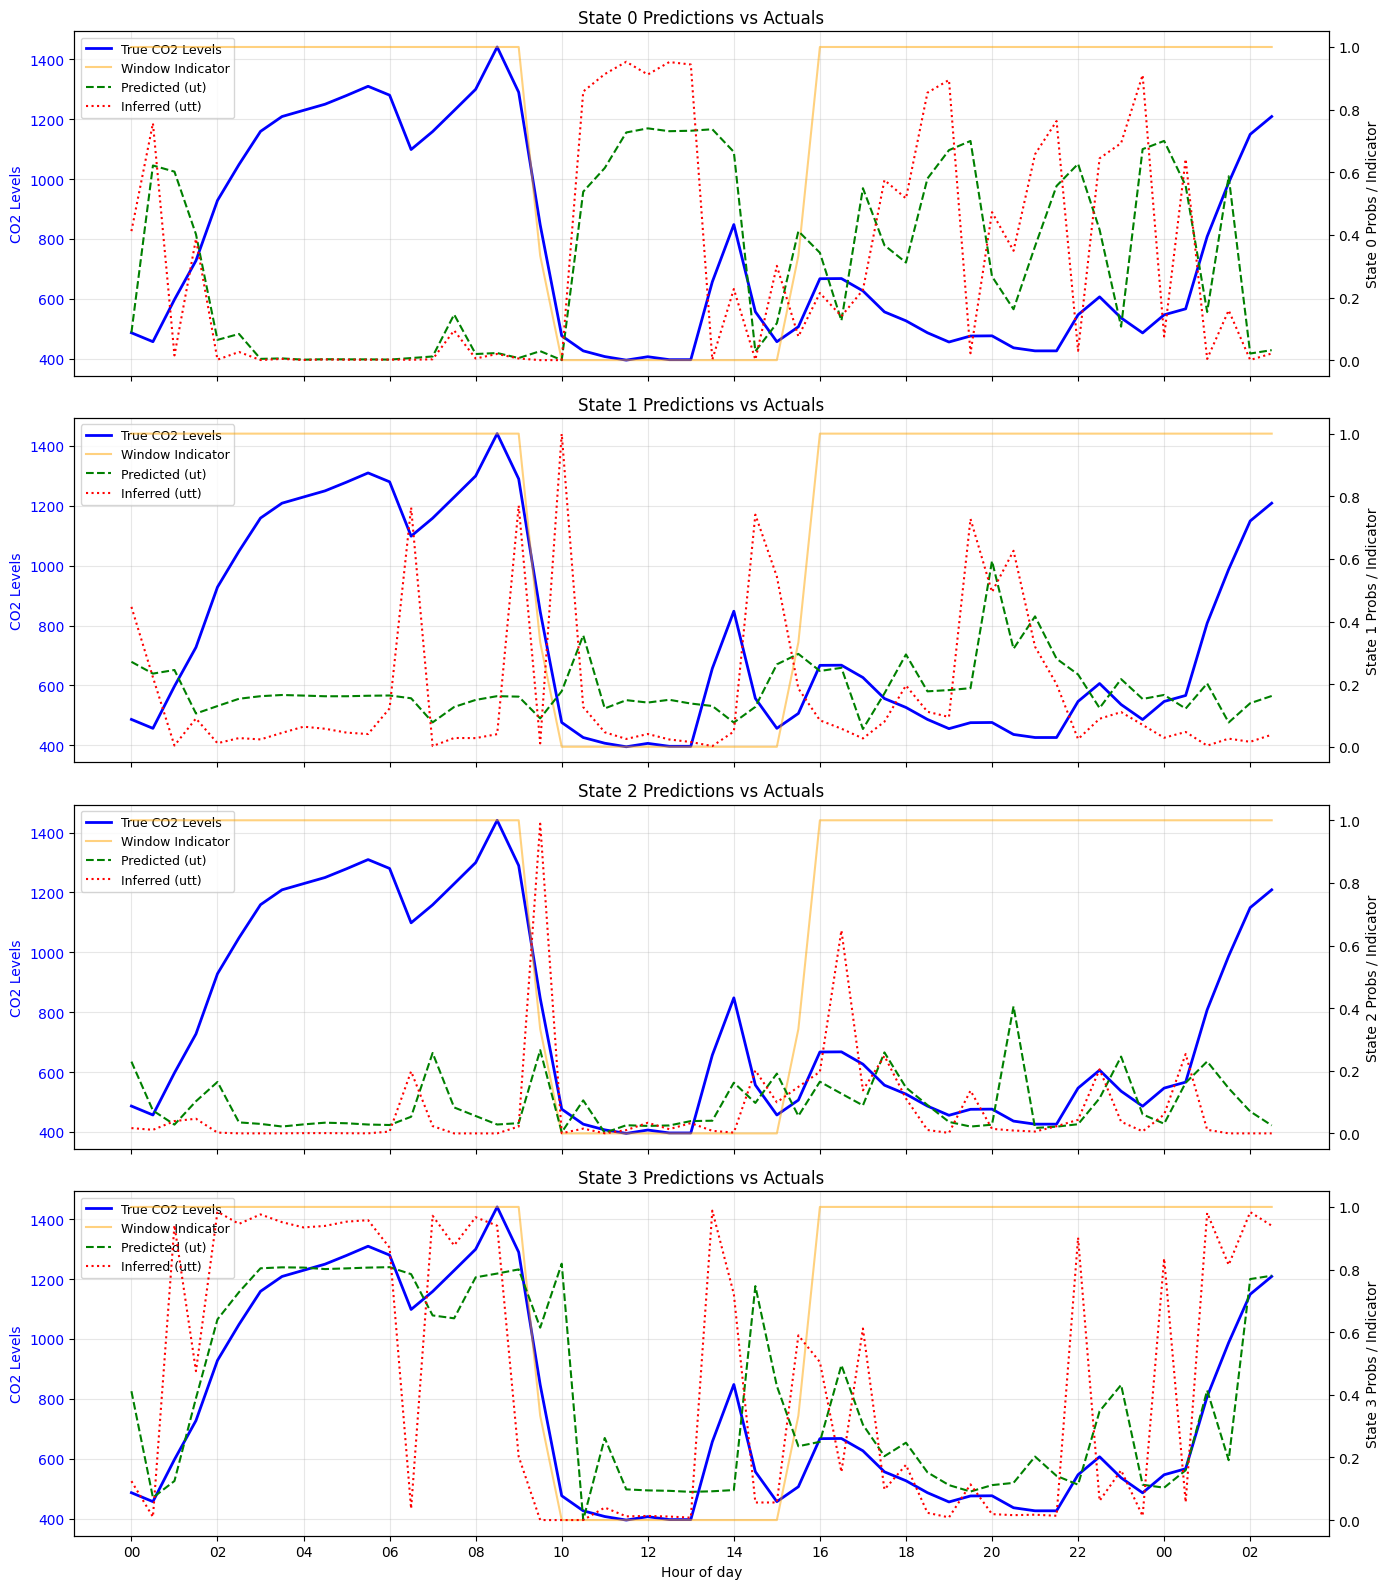

Model: covariate_hmm.pkl
Plotting from hour 0.0 for 54 timesteps (30 min each).


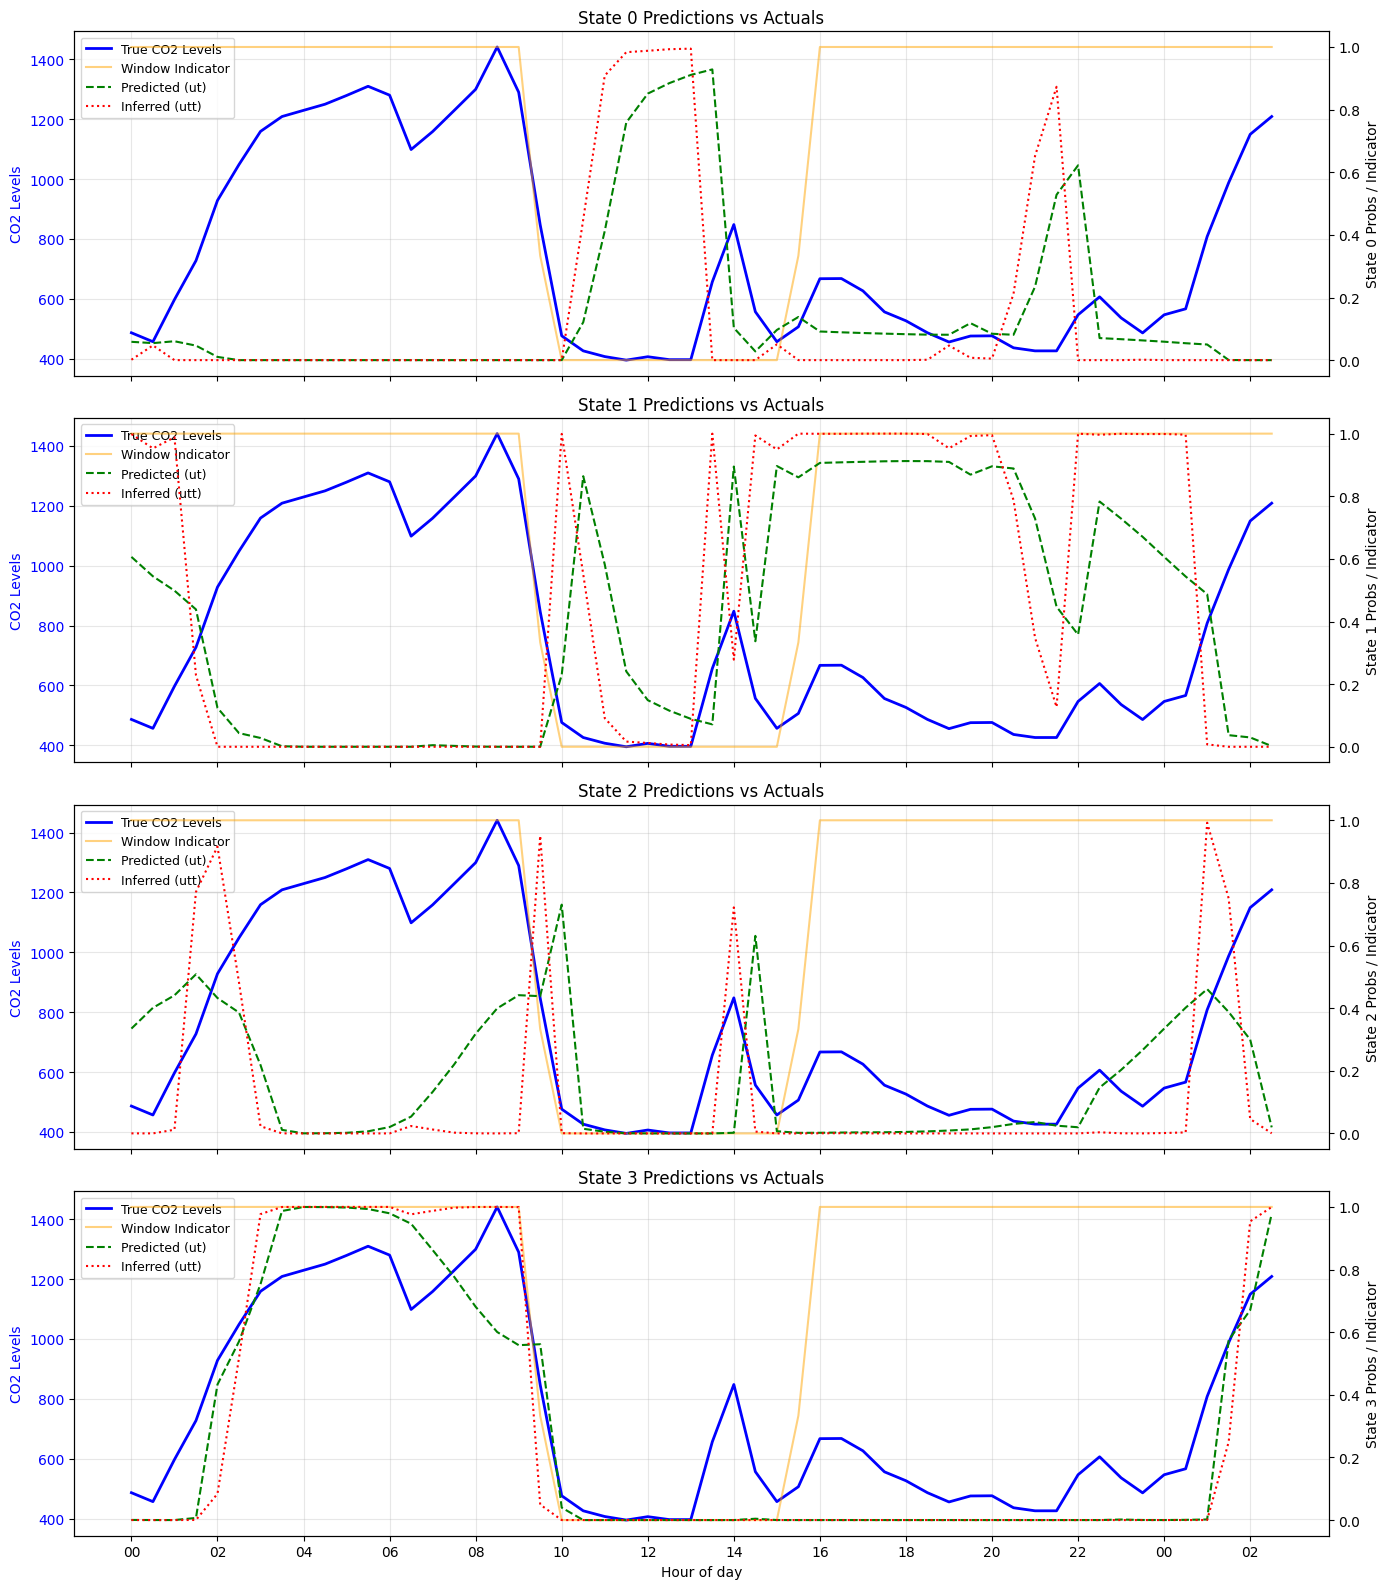

Model: ar_1_covariate_hmm.pkl
Plotting from hour 0.0 for 54 timesteps (30 min each).


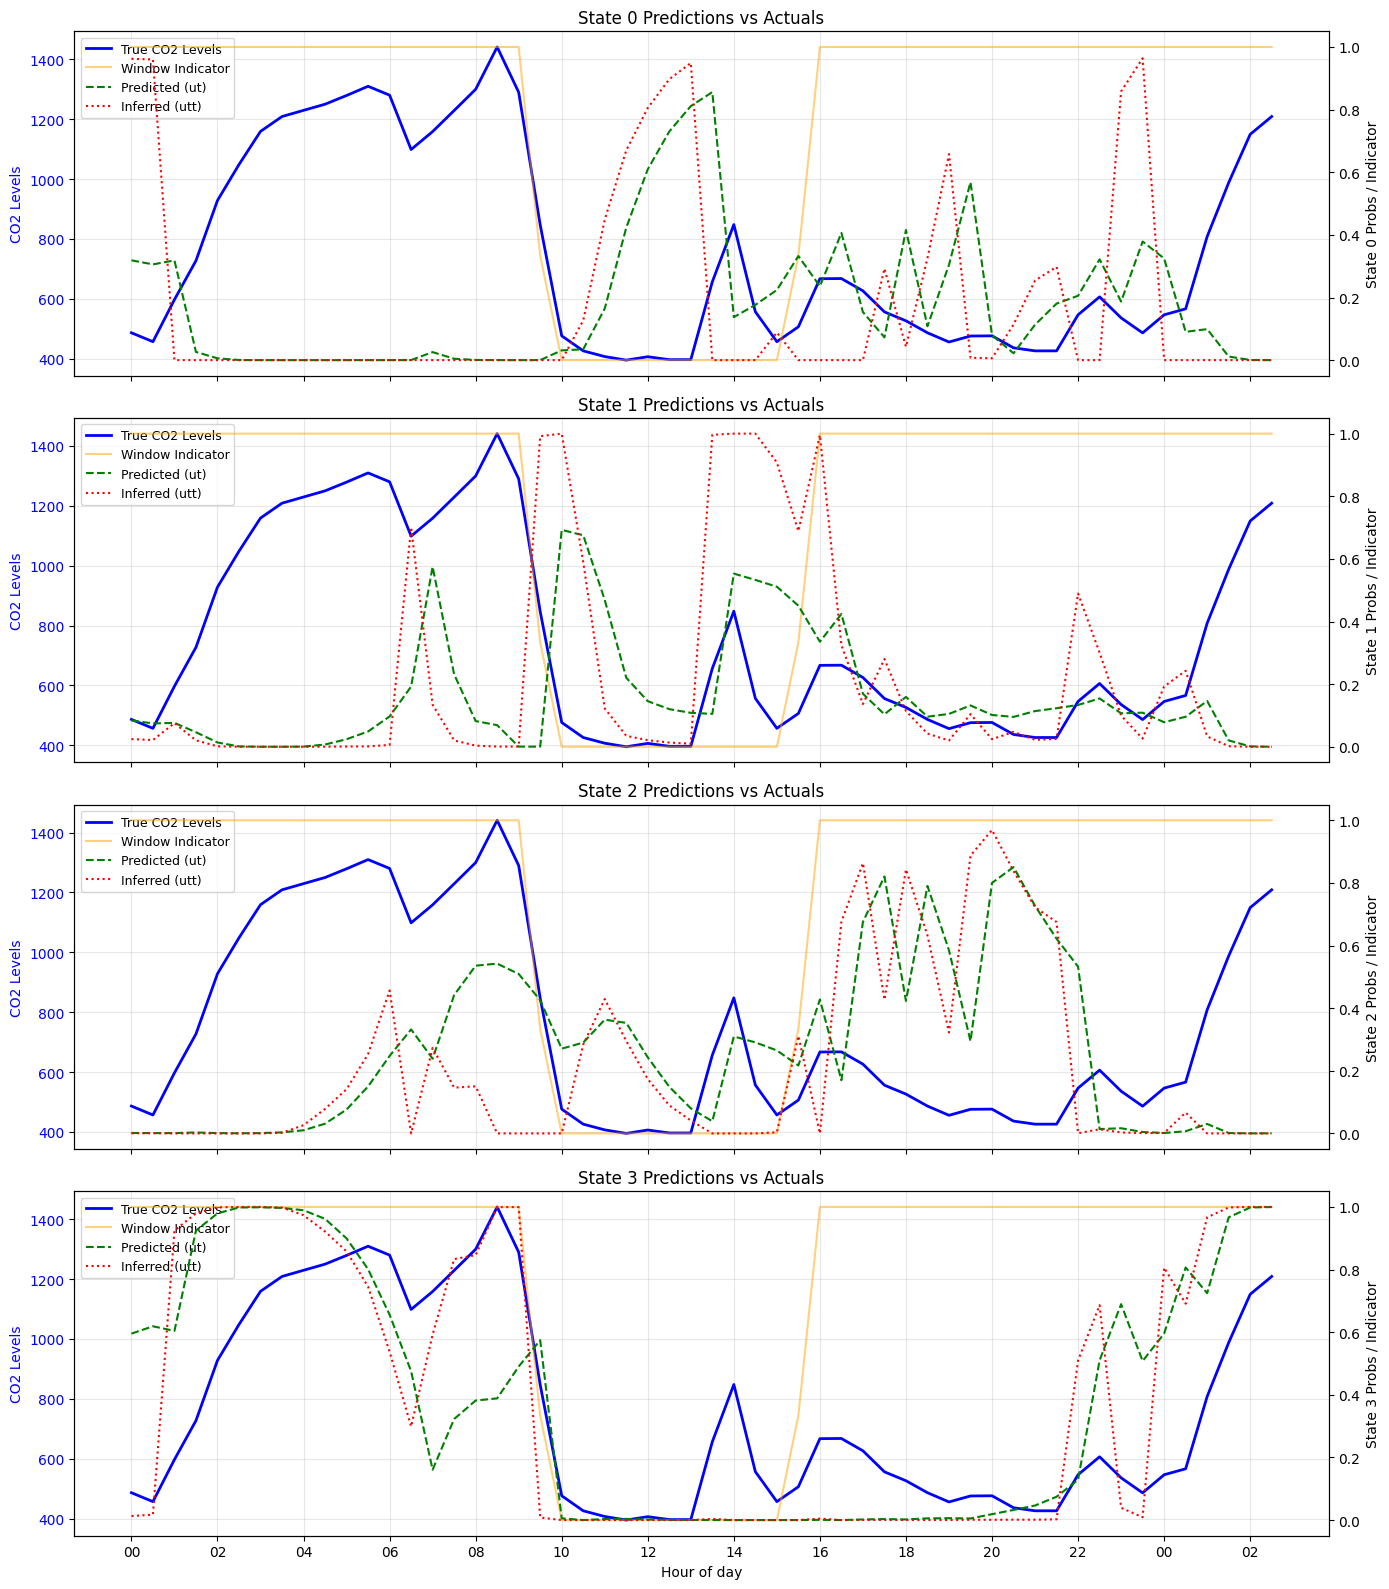

Model: ar_2_covariate_hmm.pkl
Plotting from hour 0.0 for 54 timesteps (30 min each).


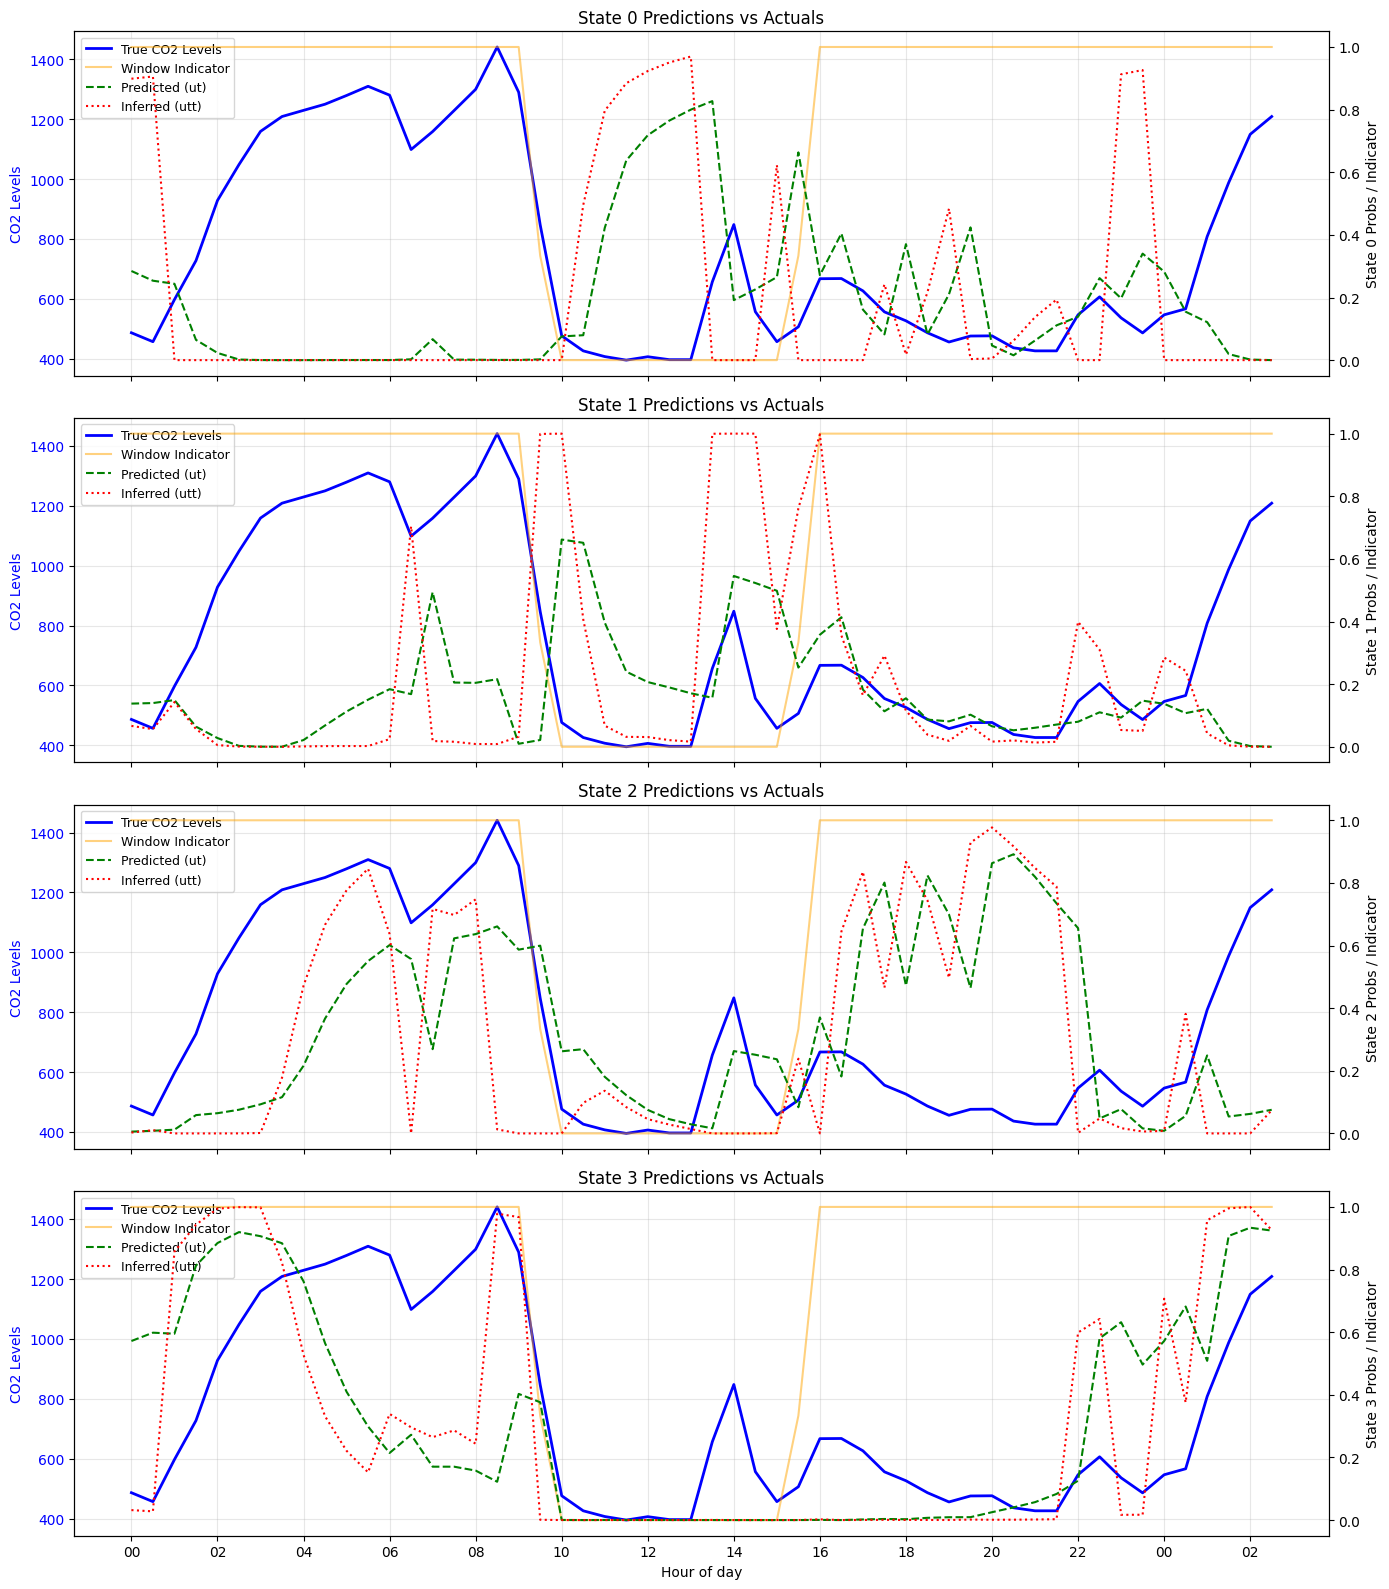

Model: ar_2_second_order_hmm.pkl
Plotting from hour 0.0 for 54 timesteps (30 min each).


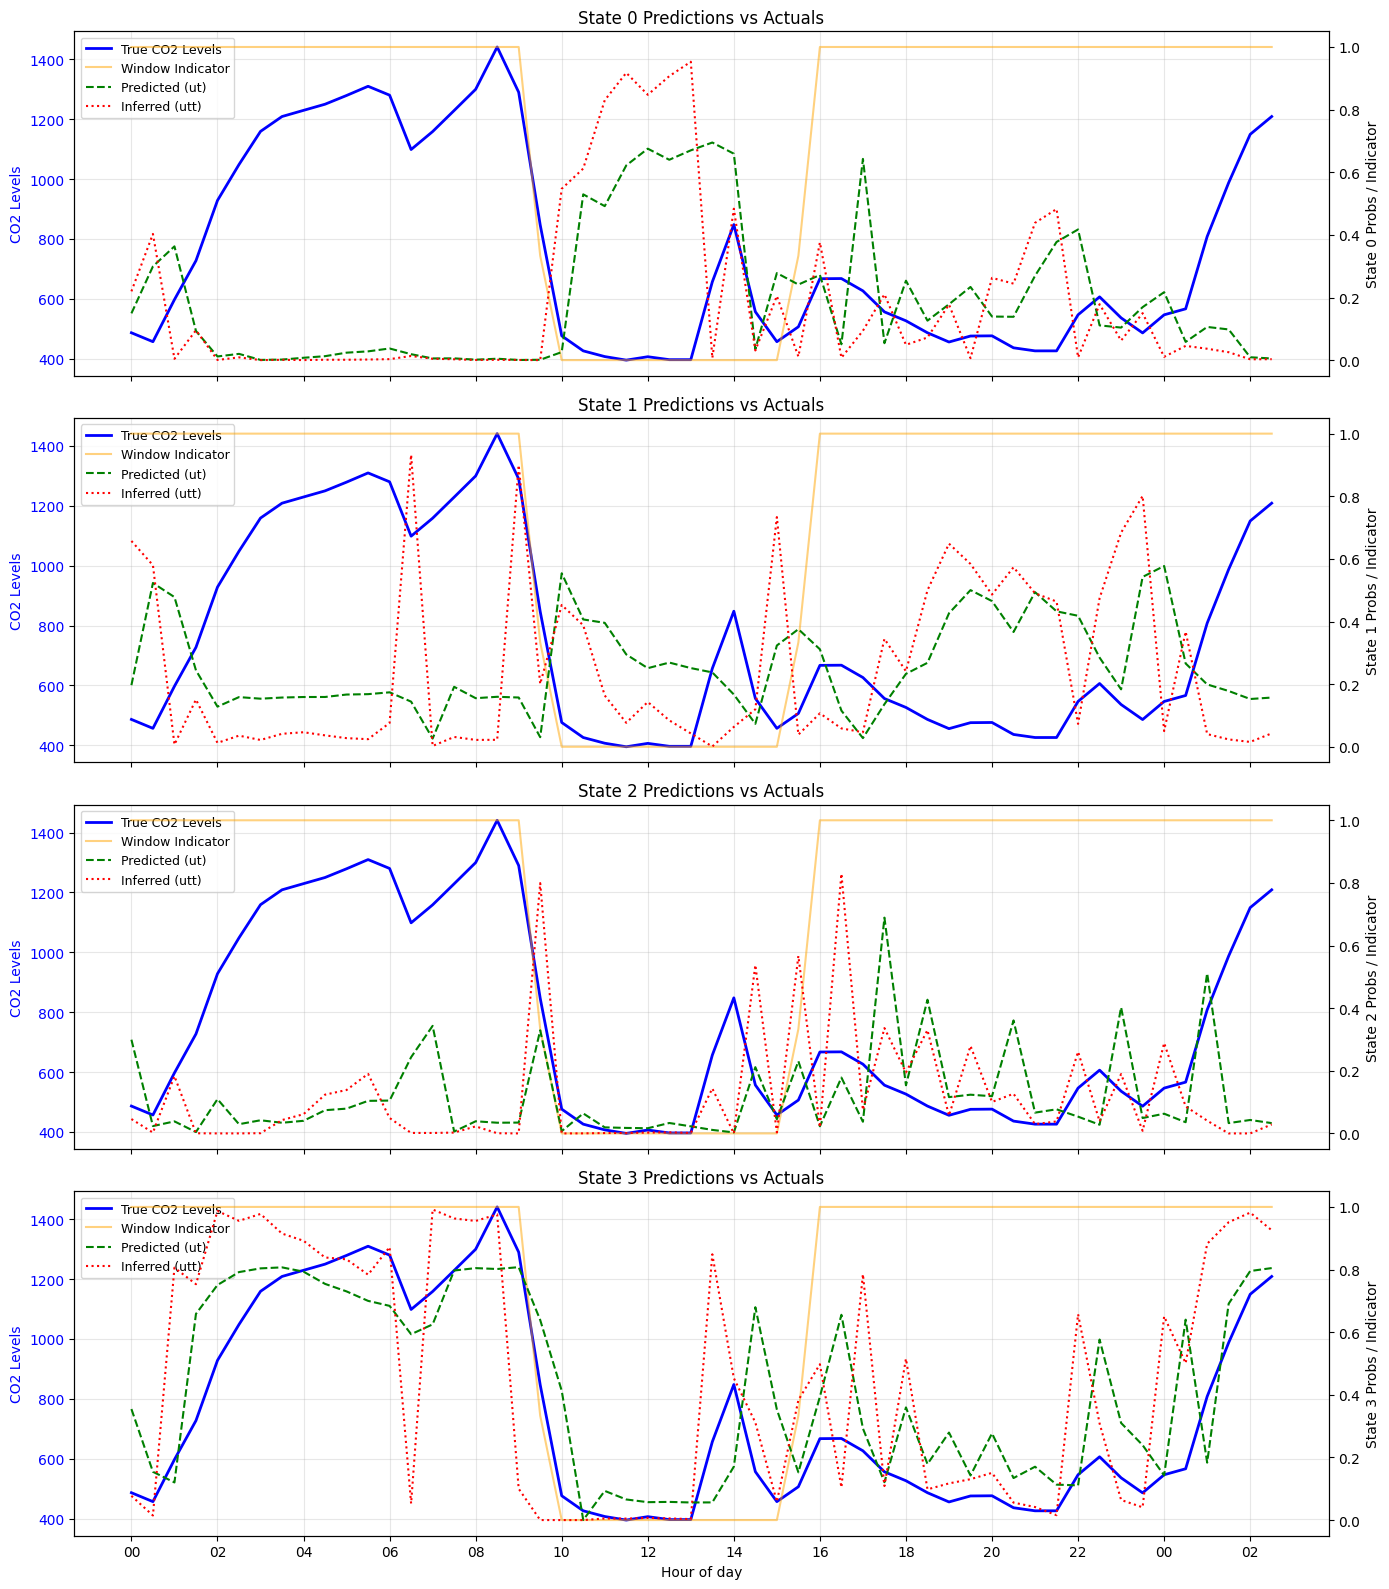

In [41]:
models = [
    "ordinary_hmm.pkl",
    "ar_hmm.pkl",
    "ar_2_hmm.pkl",
    "second_order_hmm.pkl",
    "covariate_hmm.pkl",
    "ar_1_covariate_hmm.pkl",
    "ar_2_covariate_hmm.pkl",
    "ar_2_second_order_hmm.pkl"
]

for model_name in models:
    model = load_model(BASE_MODEL_PATH + model_name)
    print("Model:", model_name)
    plot_predictions_all_states(model, ys, window_indicator, start_time=start_idx, timesteps=54)

In [42]:
model = load_model(BASE_MODEL_PATH + "covariate_hmm.pkl")

model.emission.mu(0, 0)

Array([ 400.     ,  545.4773 ,  893.19727, 1302.6771 ], dtype=float32)

In [43]:
model.emission.sigma(0, 0)

Array([ 25.437517,  78.79935 , 101.26411 , 198.52708 ], dtype=float32)

In [44]:
model.transition.beta

Array([[[  0.81855893,  31.364868  ,   0.877053  ],
        [ -0.17814511,   1.9663613 ,   0.38374075],
        [-31.500294  ,  -0.767689  ,   2.5595036 ],
        [ -1.240361  , -11.220575  ,  -9.056527  ]],

       [[  2.4046578 ,   3.1998107 ,   4.2475576 ],
        [  0.19023554,   2.653337  ,   1.6636015 ],
        [ -5.366383  ,   0.625636  ,   1.1319599 ],
        [ -5.8053126 , -32.302963  ,   6.1796756 ]]], dtype=float32)

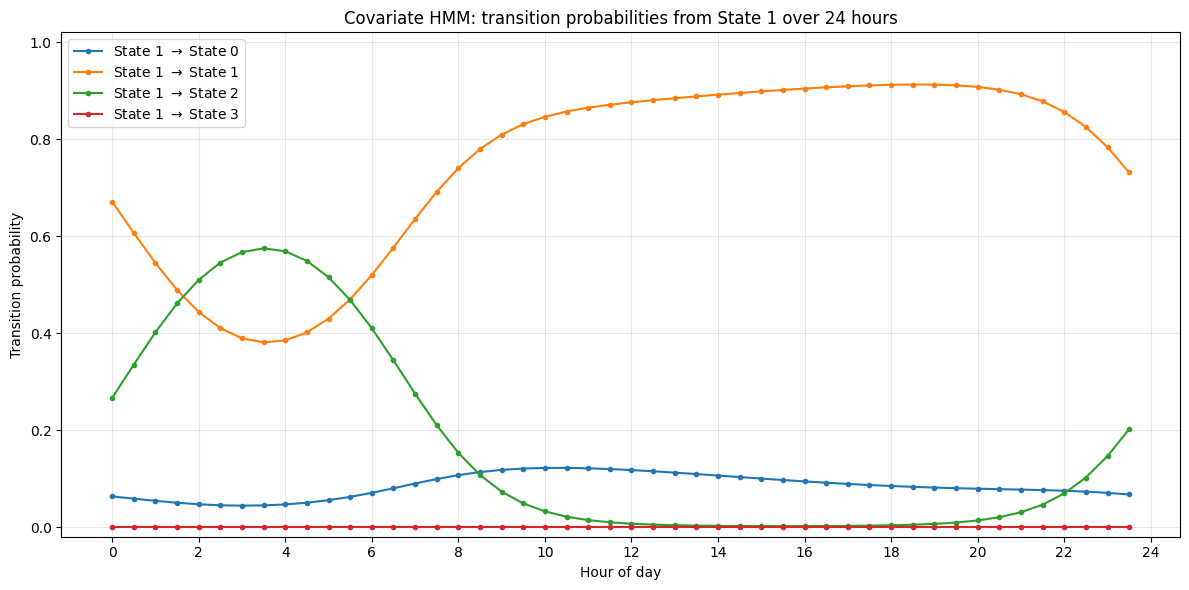

In [45]:
# Covariate HMM: how the transition probabilities from State 0 change over 24 hours.
# The dynamic transition matrix is driven by the time-of-day covariates
# (cos/sin of the half-hour index, period = 48 half-hours = 24 h), so we rebuild
# one full day of covariates and read off row 0 of the transition matrix at each step.
cov_model = load_model(BASE_MODEL_PATH + "covariate_hmm.pkl")

from_state = 1
period = 48  # half-hour steps in a day
half_hours = jnp.arange(period)
xs_day = jnp.column_stack((
    jnp.cos(2 * jnp.pi * half_hours / period),
    jnp.sin(2 * jnp.pi * half_hours / period),
))

# Row `from_state` of the transition matrix at each half-hour of the day.
probs = np.array([
    np.asarray(cov_model.transition.transition_matrix(t, xs_day)[from_state])
    for t in range(period)
])  # shape (48, num_states)

hours_axis = np.asarray(half_hours) * 0.5  # 0, 0.5, ..., 23.5

plt.figure(figsize=(12, 6))
for j in range(probs.shape[1]):
    plt.plot(hours_axis, probs[:, j], marker='o', ms=3,
             label=f'State {from_state} $\\to$ State {j}')
plt.xlabel('Hour of day')
plt.ylabel('Transition probability')
plt.title(f'Covariate HMM: transition probabilities from State {from_state} over 24 hours')
plt.xticks(range(0, 25, 2))
plt.ylim(-0.02, 1.02)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
